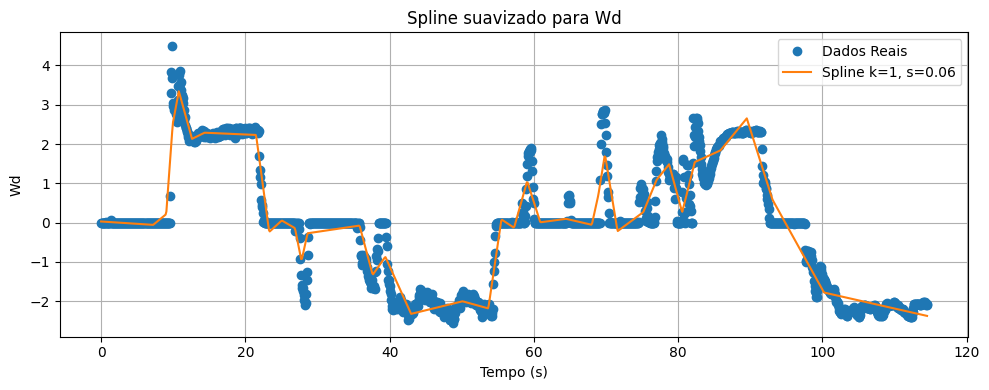

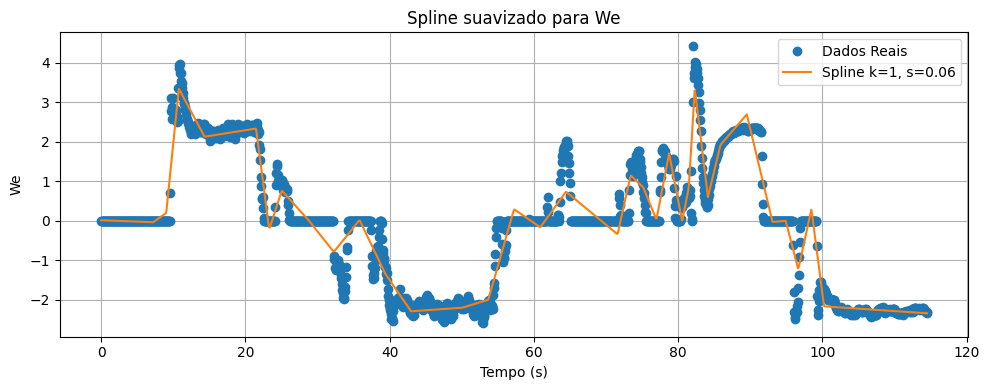

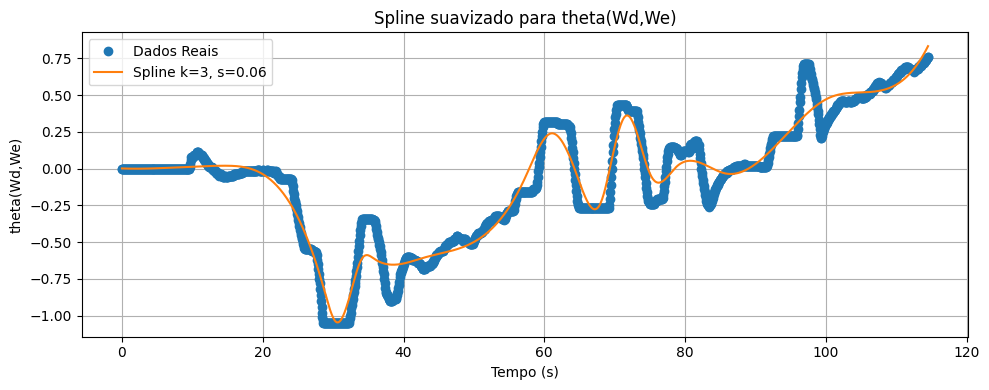

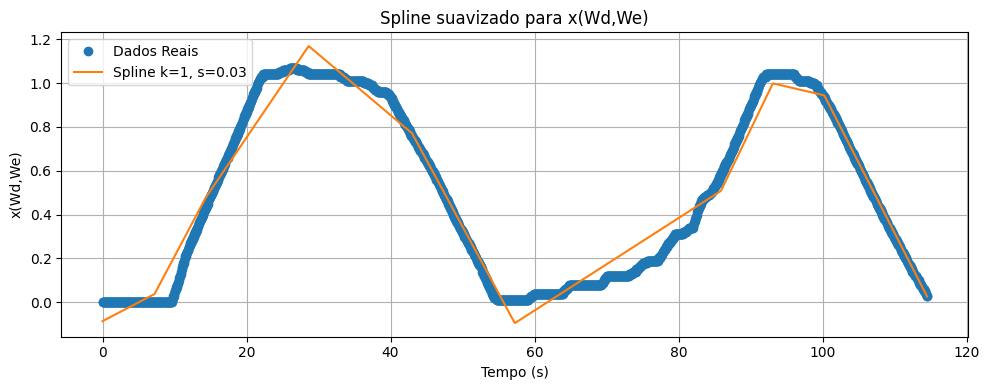

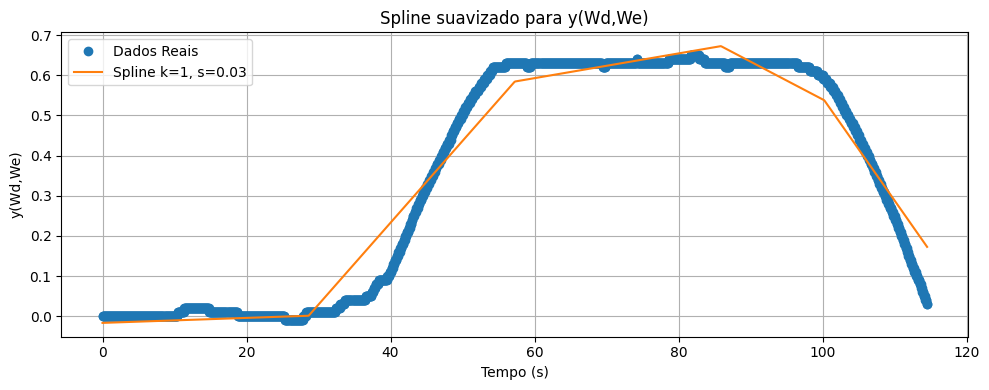

Arquivo 'DataSpline4.csv' salvo com sucesso.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# 1. Carrega e prepara os dados
data = pd.read_csv("./Data4.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

tempo = data.index.to_numpy()

# 2. Parâmetros dos splines
parametros_spline = {
    "Wd": (1, 0.06),
    "We": (1, 0.06),
    "theta(Wd,We)": (3, 0.06),
    "x(Wd,We)": (1, 0.03),
    "y(Wd,We)": (1, 0.03),
}

splines = {}
data_spline = pd.DataFrame(index=tempo)

# 3. Geração dos splines e plot dos dados reais + suavizados
for col, (k, fator_s) in parametros_spline.items():
    y = data[col].to_numpy()
    s_val = len(tempo) * np.var(y) * fator_s

    spline = UnivariateSpline(tempo, y, s=s_val, k=k)
    splines[col] = spline

    data_spline[col] = spline(tempo)

    tempo_fino = np.linspace(tempo.min(), tempo.max(), 1000)
    y_interp = spline(tempo_fino)

    plt.figure(figsize=(10, 4))
    plt.plot(tempo, y, 'o', label='Dados Reais')
    plt.plot(tempo_fino, y_interp, '-', label=f"Spline k={k}, s={fator_s}")
    plt.title(f"Spline suavizado para {col}")
    plt.xlabel("Tempo (s)")
    plt.ylabel(col)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 4. Salva dados suavizados
data_spline.to_csv("DataSpline4.csv")
print("Arquivo 'DataSpline4.csv' salvo com sucesso.")
